In [2]:
## Import necessary packages

# On Macs use osx or tk
# For Windows use qt

import numpy as np
from numpy.random import rand
from landscapeWithOcean_vectorized_JT import LandscapeWithOcean # Import methods from inside file landscapeWithOcean.py

from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from matplotlib import cm

**1. Input:**

Z: Matriks ketinggian saat ini.

NX, NY: Dimensi grid.

xx, yy: Koordinat pusat bukit.

r: Radius (jari-jari) dasar bukit.

h: Ketinggian maksimum bukit.


**2. Periodic Boundary Conditions (p.b.c.):**

dx = np.mod(x-xx+NX/2,NX)-NX/2

dy = np.mod(y-yy+NY/2,NY)-NY/2

np.mod memastikan jika pusat bukit berada di dekat tepi grid, bukit tersebut akan "tembus" ke sisi seberangnya (seperti game Snake atau peta dunia). Ini memungkinkan simulasi yang tidak terbatas oleh dinding.

**3. Kalkulasi Jarak (dr):**

dr = np.sqrt(dx\*\*2+dy\*\*2)

Ini adalah rumus Euclidean standar untuk menghitung jarak antara titik saat ini (x, y) dengan pusat bukit (xx, yy).

**4. Profil Bentuk Bukit:**

if (dr < r):
    Z[x,y] += h * (np.cos(dr/r * np.pi/2.0))**2

Jika titik berada di dalam radius r, fungsi akan menambahkan ketinggian. Penggunaan cos(...)^2 menghasilkan bentuk bukit yang mulus (smooth) di bagian puncak dan melandai dengan halus hingga nol di bagian tepi (saat dr = r, nilai cosinus menjadi 0).

In [3]:
# Z: Matriks ketinggian saat ini.
# NX, NY: Dimensi grid.
# xx, yy: Koordinat pusat bukit.
# r: Radius (jari-jari) dasar bukit (jarak maksimum dari pusat bukit k tepi/batas luar bukit)
# h: Ketinggian maksimum bukit.
def AddHill(Z,NX,NY,xx,yy,r,h):

    for x in range(NX):
        for y in range(NY):
            dx = np.mod(x-xx+NX/2,NX)-NX/2; # difference i-i0 but apply p.b.c.
            dy = np.mod(y-yy+NY/2,NY)-NY/2;
            dr = np.sqrt(dx**2+dy**2); # Euclidean, hitung jarak antara titik sekarang (x, y) dengan pusat bukit (xx, yy)
            if (dr<r): # jika titik berada dalam radius r -> tambah ketinggian
                # modifikasi nilai matriks ketinggian Z untuk titik2 yang berada di dalam jangkauan bukit
                Z[x,y] += h * (np.cos(dr/r*np.pi/2.0))**2; # shape function

    return Z

In [4]:
### Define simulation grid and initial conditions
# Menentukan jumlah sel grid -> 250 x 250 = 62,500 titik data
NX = 50*5 #number of rows (250)
NY = 50*5 #number of columns (250)

d  = 5 # grid spacing in meters (jarak satu titik ke titik berikutnya -> 5 meter)
dx = d # keep dx=dy for simplicity
dy = d # dx = dy = d

# dimensi total area simulasi dalam meter: 250 x 5 = 1250 meter atau 1.25 km
LX=NX*dx
LY=NY*dy

# small random features in topography to begin erosion
Z = rand(NX,NY)*0.1 # angka acak sangat kecil -> spy proses erosi punya jalur buat mulai
# Pembuatan Bukit Secara Acak (Looping AddHill)
for i in range(5):
    xx = rand()*NX
    yy = rand()*NY
    r  = (0.1+rand())*NX # Jari-jarinya besar
    h  = (0.1+rand())*5 # Ketinggiannya relatif rendah (maksimal sekitar 5-6 meter)
    # menciptakan bentuk dasar lahan yang bergelombang lebar.
    Z = AddHill(Z,NX,NY,xx,yy,r,h)

for i in range(5):
    xx = rand()*NX
    yy = rand()*NY
    r  = (0.1+rand())*NX/2 # Jari-jarinya lebih sempit
    h  = (0.5+rand())*10 # Ketinggiannya lebih menonjol (maksimal sekitar 15 meter)
    # menambahkan fitur seperti puncak gunung atau perbukitan yang lebih curam di atas landasan awal
    Z = AddHill(Z,NX,NY,xx,yy,r,h)

x = np.arange(NX)
y = np.arange(NY)
# buat koordinat 2D (X dan Y) yang nantinya digunakan oleh Matplotlib untuk memplot permukaan 3D
X,Y = np.meshgrid(y,x) #strange that y goes first !!! -> agar tampilan grafiknya tidak terbalik (transpose)
# saat tanah tererosi (menjadi lebih rendah), skala grafiknya tidak ikut berubah-ubah
ZMaxOrg = np.max(Z) # simpan nilai ketinggian tertinggi dari seluruh grid yang baru dibuat -> mengunci batas sumbu Z
#print(ZMaxOrg)

In [5]:
### Physical Parameters
K = 10.0e-6*1000000 # meters^(1-2m)/yr

D = 0.05 # m^2/yr

# uplift rate
# uplift = 0.03 / 600.
uplift = 0.0

In [6]:
### Model parameters

# Time step
dt = d**2 / D / 8.
#dt = d**2 / D /16. #extra small steps
print(' dt[years] = ',dt)

#Area exponent A^m, default m=1
m=1

#gradient exponent g^n, default n=1
n=1

#erosion threshold
theta_c = 10

 dt[years] =  62.5


In [7]:
# Total simulation time
T = 1000.0*62.5

# total number of iterations
n_iter = int(np.round(T/dt))
print('Number of interation: ',n_iter)

Number of interation:  1000


In [8]:
# Initialize landscape
ls = LandscapeWithOcean(NX,NY)

# parameter ini menentukan seberapa tinggi air laut menutupi kaki bukit yang dibuat
# Nilai 0.1 -> permukaan laut akan ditetapkan pada level 10% dari total ketinggian pada map (TOTAL!!!)
# menaikkan angka ini (misal ke 0.5) -> area yang terendam air (biru) akan menjadi jauh lebih luas karena permukaan air laut 'naik'.
oceanLevelParameter=0.1  # what does this parameter do?
ls.ComputeOceanVolumeFromOceanLevelParameter(Z,NX,NY,oceanLevelParameter)

ls.pool_check(Z,NX,NY)
ls.A = np.zeros((NX,NY))

Minimum elevation           1.6215288303866542
Maximum elevation           24.06042015408041
Beach level                 3.86541796275603
Ocean volume                12125.435721880518
Percentage of ocean surface 26.328000000000003


In [9]:
# Set-up figure
def init_figure():
    fig = plt.figure(figsize=(12.,6.))
    plt.show()
    return fig

def update_figure():
        plt.clf()
        ax1 = fig.add_subplot(121,projection='3d')

        # use equal x-y aspect with an explicit vertical exageration
        vert_exag = 4. # GA DIPAKE!!!
        ax1.set_xlim3d(0,max(NX,NY))
        ax1.set_ylim3d(0,max(NX,NY))
        # Skala sumbu Z (ketinggian) dikunci menggunakan ZMaxOrg agar perubahan erosi terlihat jelas secara proporsional
        ax1.set_zlim3d(0,ZMaxOrg)

        # Menampilkan bentuk permukaan tanah secara tiga dimensi
        ax1.set_title('Surface Relief')

#        surf = ax1.plot_surface(X,Y,Z, cmap = cm.terrain, rstride=1, cstride=1,
#                antialiased=False,linewidth=0)

        # Pemrosesan Data Pantai
        ZPlot = np.copy(Z)
        ZPlot[ZPlot<ls.ZBeachLevel] = ls.ZBeachLevel
        ZPlot -= ls.ZBeachLevel
        # Tampilkan surface!
        ax1.plot_surface(X,Y,ZPlot, cmap = cm.terrain, rstride=1, cstride=1,
                antialiased=False,linewidth=0)

        # Menampilkan heatmap & garis kontur -> memudahkan melihat distribusi ketinggian dan aliran air dari sudut pandang atas
        ax2 = fig.add_subplot(122,aspect='equal')
        ax2.set_title('Elevation')

        #im = ax2.pcolor(Z,cmap=cm.terrain)
        im = ax2.pcolor(ZPlot,cmap=cm.coolwarm) # water
        cs = ax2.contour(ZPlot,6,colors='k')

        # Add a color bar which maps values to colors.
        cbar = fig.colorbar(im, shrink=0.5, aspect=5)
        # Add the contour line levels to the colorbar
        cbar.add_lines(cs)

        #plt.show()
        plt.draw()
        # grafik terus diperbarui (di-refresh) setiap kali iterasi simulasi berjalan -> efek animasi perubahan lahan secara real-time
        plt.pause(0.0001)

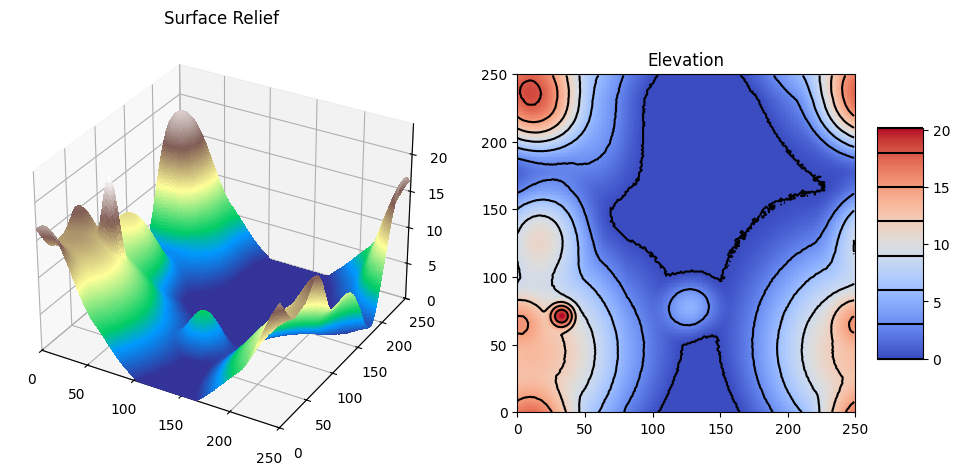

In [10]:
fig = plt.figure(figsize=(12.,6.))
update_figure()

In [11]:
# Set up figure
fig = init_figure()
update_figure()
Znew = np.copy(Z)

for it in range(1,n_iter+1):

    ls.calculate_collection_area(Z,NX,NY)
    ls.A *= dx*dy

    for i in range(NX):
        iL = np.mod(i-1,NX) # normally i-1 but observe p.b.c.
        iR = np.mod(i+1,NX) # normally i+1 but observe p.b.c.

        for j in range(NY):
            jD = np.mod(j-1,NY) # normally j-1 but observe p.b.c.
            jU = np.mod(j+1,NY) # normally j+1 but observe p.b.c.

            if ls.ocean[i,j]>0:
                Psi_z  = 0;
                Phi_z  = 0;
            else:
                if ls.drain[i,j]>0: #this cell is a drain
                    s1 = (Z[iR,j]  - Z[iL,j] )/(2.*dx)
                    s2 = (Z[i,jU]  - Z[i,jD] )/(2.*dy)
                    s3 = (Z[iR,jD] - Z[iL,jU])/(2. * np.sqrt( dx**2 + dy**2) )
                    s4 = (Z[iR,jU] - Z[iL,jD])/(2. * np.sqrt( dx**2 + dy**2) )
                    gradient = (np.sqrt(s1**2 + s2**2) + np.sqrt(s3**2 + s4**2))/2.
                    # Stream Power Law - 2nd part of the main equation (Erosi oleh Air)
                    Psi_z = K * ( ls.A[i,j]**m * gradient**n - theta_c)

                elif ls.drainage[i,j]>0: #this cell is a drainage point (it drains a pool)

                    if (Z[i,j]>=Z[iR,j]) and ls.pool[iR,j]!=ls.drainage[i,j]:
                        gradient = (Z[i,j]-Z[iR,j])/dx #pool is on my left, I drain to the right, use this gradiant
                    elif (Z[i,j]>=Z[iL,j]) and ls.pool[iL,j]!=ls.drainage[i,j]:
                        gradient = (Z[i,j]-Z[iL,j])/dx
                    elif (Z[i,j]>=Z[i,jU]) and ls.pool[i,jU]!=ls.drainage[i,j]:
                        gradient = (Z[i,j]-Z[i,jU])/dy
                    elif (Z[i,j]>=Z[i,jD]) and ls.pool[i,jD]!=ls.drainage[i,j]:
                        gradient = (Z[i,j]-Z[i,jD])/dy
                    else:
                        gradient = 0.02 # ??? This does happen (maybe when two pools merge)
                    Psi_z = K * ( ls.A[i,j]**m * gradient**n - theta_c)

                else: #this cell is a pool, assume it has some mass diffusion but no erosion!
                    Psi_z = 0.

                if (Psi_z<0):
                    Psi_z = 0.

                # diffusion term - 1st part of the main equation (tanah yang longsor perlahan atau terkikis angin)
                Phi_z = D * ( (Z[iR,j] - 2.*Z[i,j] + Z[iL,j]) / dx**2 \
                            + (Z[i,jU] - 2.*Z[i,j] + Z[i,jD]) / dx**2 )

            # Logika Perubahan Ketinggian: Ketinggian Lama + (Efek Halus (diffusion) - Efek Erosi (air) + Pengangkatan Tektonik).
            # Karena nilai uplift 0.0 -> gaya yang bekerja hanya penghancuran/perataan bukit
            Znew[i,j] = Z[i,j] + (Phi_z - Psi_z + uplift )*dt

            dZdt= (Znew[i,j] - Z[i,j]) / dt
            CFL = abs(dZdt) * dt / min(dx,dy)
            # Jika perubahan ketinggian terlalu ekstrem dalam satu langkah waktu (dt), simulasi bisa menjadi tidak stabil (meledak).
            # Jika muncul peringatan ini, artinya dt perlu diperkecil agar simulasi tetap akurat
            if (CFL>1.0):
                print('\nWarning: Time step of',dt,'is probably too large. Safer would be:',dt/CFL)

            if (Znew[i,j]<0.):
                Znew[i,j] = 0. # yes, this does happen at the boundary when kept at zero

    #Znew[0,:] = 0.0 # resets front boundary to 0
    Z = np.copy(Znew)

    ls.pool_check(Z,NX,NY)

    if (np.mod(it,50)==0):
        print(it,end='')
        #update_figure()
        print(' Ocean level=',ls.ZBeachLevel,' Ocean surface fraction=',100*ls.AOcean/(NX*NY));
        #plt.savefig('erosion_16_vectorized_14min'+str(it)+'.pdf', bbox_inches='tight')
        fig = plt.figure(figsize=(12.,6.))
        update_figure()
    else:
        print('.',end='')

update_figure()
print(' Simulation finished.')


Output hidden; open in https://colab.research.google.com to view.